1)Take Tips dataset from seaborn library and create an ML model which will predict the tips given by new customers.

#Problem Statement :

“The objective of this project is to build a Machine Learning model that predicts the tip amount given by restaurant customers based on features such as total bill, number of people, gender, smoking status, day, and time.”

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.load_dataset('tips') directly downloads dataset
No need to manually download files
Dataset contains real restaurant tipping data

In [2]:
#Load Dataset 
tips=sns.load_dataset("tips")

In [3]:
#First few rows
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


total_bill → total bill amount
tip → tip given (our target variable 🎯)
sex, smoker, day, time → categorical features
size → number of people

Step 3: Basic Data Understanding 
Helps understand structure before modeling
No missing values → good dataset quality

In [4]:
# Check dataset shape (rows, columns)
print("Shape:", tips.shape)

# Check column names
print("Columns:", tips.columns)

# Check data types and null values
print(tips.info())

Shape: (244, 7)
Columns: Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


#Visualize Relationships

As total bill increases → tip also increases
Strong positive relationship → good for ML model

Step 4: Statistical Summary
Shows mean, min, max of numeric columns
Helps detect outliers

In [ ]:
# Step 4: Check null values 
print(tips.isnull().sum())

# Optional check
print(tips.isnull().values.any())

# Step 5: Statistical summary
print(tips.describe())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
False
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


# Visualize missing values
Helps visually identify missing data
Useful for large datasets

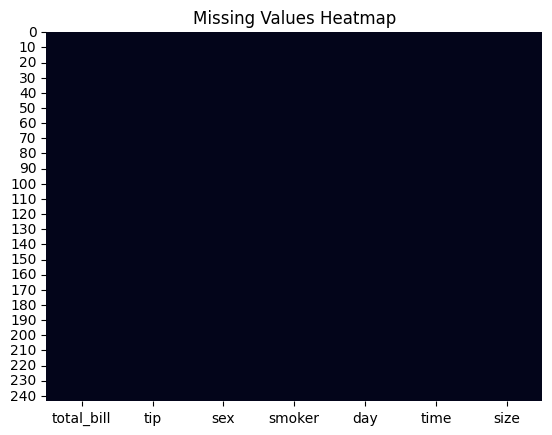

In [6]:
# Visualize missing values
sns.heatmap(tips.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

Step 5: Univariate Analysis
Most tips are between 2 to 4
Slight right skew 

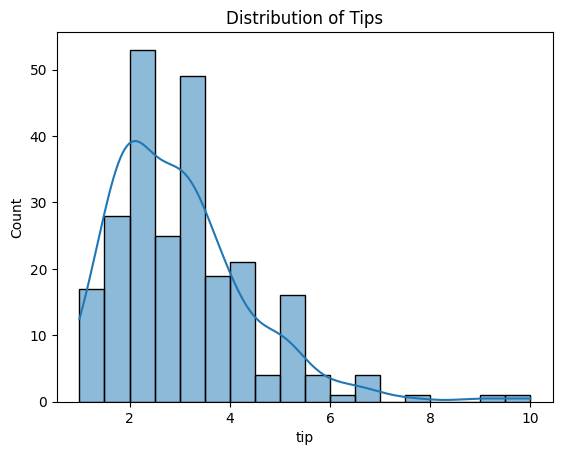

In [7]:
# Distribution of tip
sns.histplot(tips['tip'], kde=True)
plt.title("Distribution of Tips")
plt.show()

Step 6: Bivariate Analysis
Strong positive relationship
Higher bill → higher tip

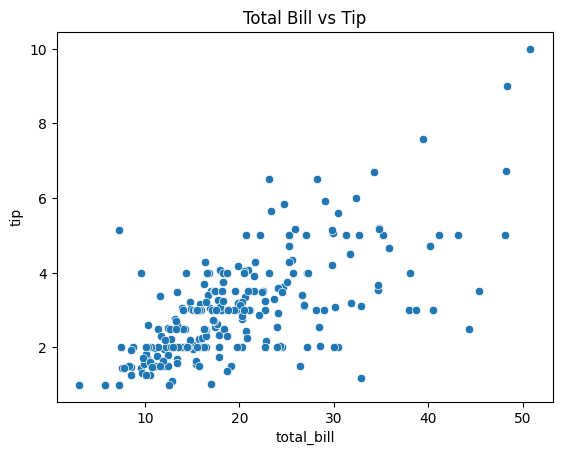

In [8]:
# Relationship between total bill and tip
sns.scatterplot(x='total_bill', y='tip', data=tips)
plt.title("Total Bill vs Tip")
plt.show()

Step 7: Categorical Analysis
Tips vary by day (weekends slightly higher)
Useful feature for model

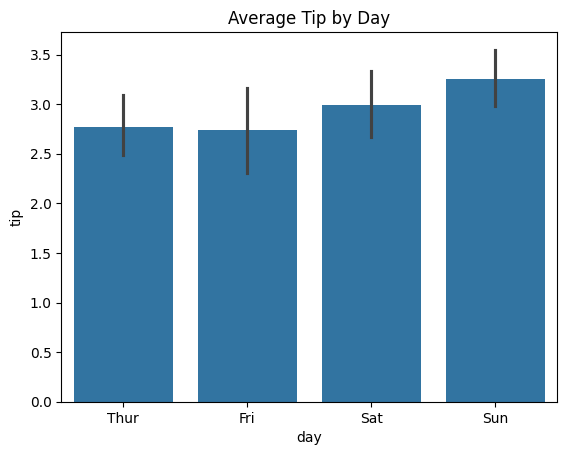

In [9]:
# Average tip based on day
sns.barplot(x='day', y='tip', data=tips)
plt.title("Average Tip by Day")
plt.show()

Step 8: Feature Engineering
Feature engineering improves model understanding
Tip % shows customer generosity

In [10]:
# Create new feature: tip percentage
tips['tip_percentage'] = tips['tip'] / tips['total_bill']

# Display updated data
print(tips.head())

   total_bill   tip     sex smoker  day    time  size  tip_percentage
0       16.99  1.01  Female     No  Sun  Dinner     2        0.059447
1       10.34  1.66    Male     No  Sun  Dinner     3        0.160542
2       21.01  3.50    Male     No  Sun  Dinner     3        0.166587
3       23.68  3.31    Male     No  Sun  Dinner     2        0.139780
4       24.59  3.61  Female     No  Sun  Dinner     4        0.146808


Step 9: Encoding Categorical Variables
Converts text → numbers
Required for ML models

In [11]:
# Convert categorical variables into numeric
tips_encoded = pd.get_dummies(tips, drop_first=True)

# Display encoded dataset
print(tips_encoded.head())

   total_bill   tip  size  tip_percentage  sex_Female  smoker_No  day_Fri  \
0       16.99  1.01     2        0.059447        True       True    False   
1       10.34  1.66     3        0.160542       False       True    False   
2       21.01  3.50     3        0.166587       False       True    False   
3       23.68  3.31     2        0.139780       False       True    False   
4       24.59  3.61     4        0.146808        True       True    False   

   day_Sat  day_Sun  time_Dinner  
0    False     True         True  
1    False     True         True  
2    False     True         True  
3    False     True         True  
4    False     True         True  


Step 10: Define Features and Target
X = input data
y = what we want to predict

In [12]:
# Features (independent variables)
X = tips_encoded.drop('tip', axis=1)

# Target variable
y = tips_encoded['tip']

Step 11: Train-Test Split
80% training, 20% testing
Prevents overfitting

In [13]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Step 12: Feature Scaling
Scaling improves model performance
Especially important for regression

In [14]:
# Scale numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 13: Model Training
Model learns patterns from training data

In [15]:
# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Step 14: Prediction
Model is now used for unseen data

In [16]:
# Predict on test data
y_pred = model.predict(X_test)

Step 15: Model Evaluation
R² closer to 1 = better model
MSE lower = better predictions

In [17]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.2426512567026786
R2 Score: 0.8058745445482828


Step 16: Feature Importance
Shows which features influence tips the most
Helps explain model (important for interviews)

In [18]:
# Get model coefficients
coefficients = pd.DataFrame(model.coef_, columns=['Coefficient'])

print(coefficients)

   Coefficient
0     1.207055
1     0.097748
2     0.943800
3    -0.018641
4     0.162950
5     0.013940
6    -0.000762
7    -0.083634
8    -0.014391


Step 17: Predict New Customer
Model can now predict real-world scenarios

In [19]:
# Example new data (must match training columns)
new_data = X_test[0:1]

# Predict tip
prediction = model.predict(new_data)

print("Predicted Tip:", prediction)

Predicted Tip: [3.14375911]


This project focuses on applying Linear Regression to predict restaurant tips. I performed EDA, preprocessing, and basic feature engineering to understand the data. The model shows that total bill is the main factor influencing tips. This project helped me build a strong foundation in regression and model evaluation.